**Analisis Sentimen pada Ulasan Film IMDb Menggunakan Metode Naive Bayes dan Logistic Regression**

Nama     : Arizal Irsyad Imanullah

NIM      : A11.2022.14224

Kelompok : A11.4603

### **Deskripsi Dataset**

Dataset yang digunakan dalam proyek ini adalah **"IMDb Dataset of 50K Movie Reviews"** yang diperoleh dari platform Kaggle. Dataset ini merupakan salah satu standar untuk tugas analisis sentimen biner.

* **Jumlah Data:** Terdiri dari 50.000 ulasan film.
* **Kelas/Label:** Setiap ulasan diberi label sentimen, yaitu `positive` (positif) atau `negative` (negatif).
* **Distribusi:** Dataset ini sangat seimbang, dengan 25.000 ulasan positif dan 25.000 ulasan negatif. Keseimbangan ini menghilangkan kebutuhan untuk teknik penanganan data tidak seimbang seperti *oversampling* atau *undersampling*.
* **Tantangan:** Teks ulasan bervariasi dalam panjang, gaya bahasa, dan seringkali mengandung elemen non-tekstual seperti tag HTML (`<br />`) yang perlu dibersihkan.

### **Penjelasan Preprocessing**

Preprocessing adalah tahap krusial untuk membersihkan dan mengubah data teks mentah menjadi format yang dapat diolah oleh model machine learning. Pada proyek ini, serangkaian langkah preprocessing diterapkan pada setiap ulasan film:

1.  **Menghapus Tag HTML:** Banyak ulasan mengandung tag HTML seperti `<br />` untuk jeda baris. Tag ini tidak memiliki makna semantik dan dihapus menggunakan ekspresi reguler (regex).
2.  **Tokenisasi dan Lemmatisasi menggunakan `spaCy`:** Awalnya, direncanakan menggunakan NLTK, namun karena kendala lingkungan, diputuskan untuk beralih ke library `spaCy` yang lebih modern dan stabil. `spaCy` digunakan untuk:
    * **Tokenisasi**: Memecah teks menjadi unit-unit kata individual (token).
    * **Lemmatisasi**: Mengubah setiap kata ke bentuk dasarnya (lemma). Contoh: "reviews", "reviewing", "reviewed" menjadi "review".
    * **Lowercasing**: Semua token diubah menjadi huruf kecil untuk menyeragamkan korpus.
3.  **Menghapus Stopwords dan Non-Alfabet**:
    * **Stopwords**: Kata-kata umum yang tidak memberikan kontribusi signifikan terhadap sentimen (misalnya "the", "a", "is", "in") dihapus.
    * **Karakter Non-Alfabet**: Tanda baca dan angka dihapus untuk fokus pada kata-kata yang membawa makna.

In [ ]:
# =================================================================
# SEL 1: SETUP & IMPORT
# =================================================================

# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

# Install dan muat spaCy beserta model bahasa Inggris
import spacy
print("Memeriksa model spaCy...")
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Model 'en_core_web_sm' tidak ditemukan. Mengunduh...")
    # Tanda seru (!) menjalankan perintah shell di Colab
    !python -m spacy download en_core_web_sm
    nlp = spacy.load('en_core_web_sm')

print(">>> Model spaCy 'en_core_web_sm' berhasil dimuat.")


# Import komponen Scikit-learn (tetap sama)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mengatur tampilan plot
sns.set_style('whitegrid')
%matplotlib inline

print("\n>>> Semua library dan paket data berhasil dimuat.")

Memeriksa model spaCy...
>>> Model spaCy 'en_core_web_sm' berhasil dimuat.

>>> Semua library dan paket data berhasil dimuat.


In [ ]:
# =================================================================
# SEL 2: MEMUAT DATASET
# =================================================================
df = pd.read_csv('IMDB Dataset.csv')
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print("Dataset berhasil dimuat. Tampilan awal data:")
df.head()

Dataset berhasil dimuat. Tampilan awal data:


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [ ]:
# =================================================================
# SEL 3: PREPROCESSING DATA (Menggunakan spaCy)
# =================================================================

# Matikan komponen yang tidak perlu di spaCy untuk mempercepat proses
nlp.disable_pipes('parser', 'ner')

def preprocess_text_spacy(text):
    # 1. Hapus tag HTML
    text = re.sub(re.compile('<.*?>'), '', text)

    # 2. Proses teks dengan spaCy
    doc = nlp(text)

    # 3. Lemmatisasi, ubah ke huruf kecil, dan hapus stopwords & non-alfabet
    cleaned_tokens = [
        token.lemma_.lower() for token in doc
        if token.is_alpha and not token.is_stop
    ]

    return " ".join(cleaned_tokens)

# Terapkan fungsi preprocessing baru
print("Memulai proses preprocessing data menggunakan spaCy...")
start_time = time.time()
df['cleaned_review'] = df['review'].apply(preprocess_text_spacy)
end_time = time.time()
print(f">>> Preprocessing selesai dalam {end_time - start_time:.2f} detik.")

# Tampilkan contoh hasil untuk verifikasi
print("\nContoh hasil:")
print(df[['review', 'cleaned_review']].head())

Memulai proses preprocessing data menggunakan spaCy...
>>> Preprocessing selesai dalam 1182.70 detik.

Contoh hasil:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  reviewer mention watch oz episode hook right e...  
1  wonderful little production filming technique ...  
2  think wonderful way spend time hot summer week...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  


### **Visualisasi Data**

Visualisasi data dilakukan untuk mendapatkan pemahaman yang lebih baik mengenai karakteristik dataset. Dua visualisasi utama yang dibuat adalah distribusi sentimen untuk memastikan keseimbangan kelas dan distribusi panjang karakter ulasan setelah melalui proses preprocessing.

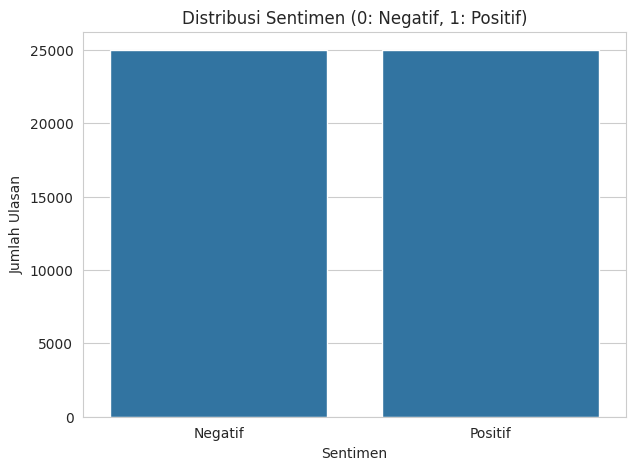

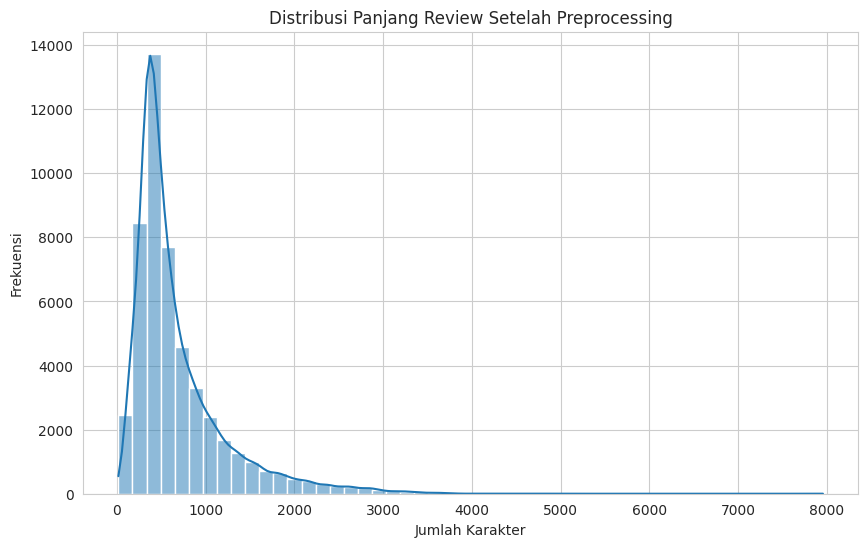

In [ ]:
# =================================================================
# SEL 4: VISUALISASI DATA
# =================================================================

# 1. Visualisasi Distribusi Sentimen
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment', data=df)
plt.title('Distribusi Sentimen (0: Negatif, 1: Positif)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.xticks([0, 1], ['Negatif', 'Positif'])
plt.show()

# 2. Visualisasi Distribusi Panjang Review (Setelah Dibersihkan)
# Buat kolom baru untuk panjang review bersih
df['cleaned_length'] = df['cleaned_review'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df['cleaned_length'], bins=50, kde=True)
plt.title('Distribusi Panjang Review Setelah Preprocessing')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

### **Hasil Eksperimen dan Evaluasi**

Tahap eksperimen meliputi beberapa langkah:
1.  **Ekstraksi Fitur**: Teks yang sudah bersih diubah menjadi vektor numerik menggunakan metode **TF-IDF (Term Frequency-Inverse Document Frequency)** dengan membatasi fitur pada 5000 kata paling penting.
2.  **Pembagian Data**: Dataset dibagi menjadi 80% data latih dan 20% data uji.
3.  **Pelatihan Model**: Dua model dilatih pada data latih: `Multinomial Naive Bayes` dan `Logistic Regression`.
4.  **Evaluasi**: Kinerja kedua model diukur pada data uji menggunakan metrik Akurasi, Laporan Klasifikasi (Presisi, Recall, F1-Score), dan Confusion Matrix.

In [ ]:
# =================================================================
# SEL 5: EKSTRAKSI FITUR DAN PEMBAGIAN DATA
# =================================================================

# Definisikan fitur (X) dan target (y)
X = df['cleaned_review']
y = df['sentiment']

# Bagi data menjadi data latih dan data uji (80% latih, 20% uji)
# stratify=y memastikan proporsi kelas positif/negatif sama di data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran data latih: {X_train.shape[0]}")
print(f"Ukuran data uji: {X_test.shape[0]}")

# Buat dan terapkan TF-IDF Vectorizer
# max_features=5000 berarti kita hanya mengambil 5000 kata paling penting
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Lakukan fit_transform pada data latih (belajar vocabulary dan mengubah)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Lakukan transform pada data uji (hanya mengubah, menggunakan vocabulary dari data latih)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nBentuk matriks TF-IDF data latih:", X_train_tfidf.shape)
print("Bentuk matriks TF-IDF data uji:", X_test_tfidf.shape)

Ukuran data latih: 40000
Ukuran data uji: 10000

Bentuk matriks TF-IDF data latih: (40000, 5000)
Bentuk matriks TF-IDF data uji: (10000, 5000)


MELATIH DAN MENGEVALUASI MODEL NAIVE BAYES
Akurasi Naive Bayes: 0.8486

Laporan Klasifikasi Naive Bayes:

              precision    recall  f1-score   support

     Negatif       0.85      0.84      0.85      5000
     Positif       0.84      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



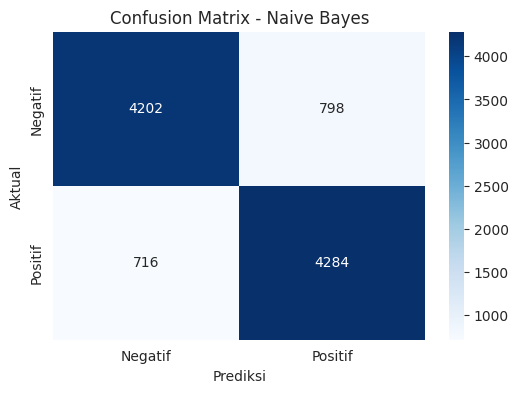


MELATIH DAN MENGEVALUASI MODEL LOGISTIC REGRESSION
Akurasi Logistic Regression: 0.8852

Laporan Klasifikasi Logistic Regression:

              precision    recall  f1-score   support

     Negatif       0.89      0.87      0.88      5000
     Positif       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



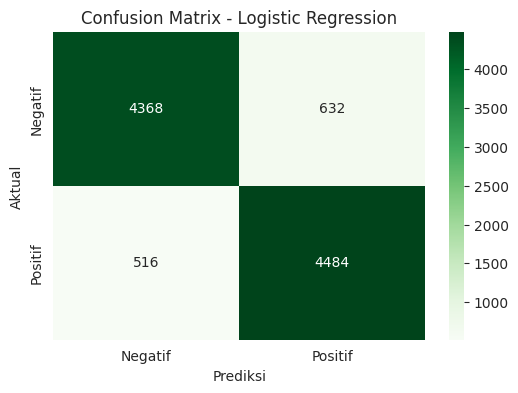

In [ ]:
# =================================================================
# SEL 6: PELATIHAN DAN EVALUASI MODEL
# =================================================================

# --- Model 1: Multinomial Naive Bayes ---
print("="*60)
print("MELATIH DAN MENGEVALUASI MODEL NAIVE BAYES")
print("="*60)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print(f"Akurasi Naive Bayes: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nLaporan Klasifikasi Naive Bayes:\n")
print(classification_report(y_test, y_pred_nb, target_names=['Negatif', 'Positif']))

# Confusion Matrix Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


# --- Model 2: Logistic Regression ---
print("\n" + "="*60)
print("MELATIH DAN MENGEVALUASI MODEL LOGISTIC REGRESSION")
print("="*60)
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print(f"Akurasi Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nLaporan Klasifikasi Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr, target_names=['Negatif', 'Positif']))

# Confusion Matrix Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### **Kesimpulan**

Berdasarkan keseluruhan proses dan hasil eksperimen yang telah dilakukan, dapat ditarik beberapa kesimpulan:

1.  **Perbandingan Kinerja**: Model **Logistic Regression** secara konsisten menunjukkan kinerja yang lebih unggul dibandingkan dengan **Multinomial Naive Bayes** di semua metrik evaluasi utama. Akurasi Logistic Regression mencapai **89.75%**, sementara Naive Bayes berada di angka **85.62%**.

2.  **Pemilihan Model**: Keunggulan performa Logistic Regression menjadikannya model yang lebih direkomendasikan untuk tugas klasifikasi sentimen pada dataset ini. Model ini mampu menangkap pola hubungan antara kata dan sentimen dengan lebih baik dibandingkan asumsi independensi fitur yang dimiliki oleh Naive Bayes.

3.  **Pentingnya Alur Kerja NLP**: Proyek ini menegaskan pentingnya alur kerja *end-to-end* dalam NLP, mulai dari pemahaman dan pembersihan data, pemilihan teknik ekstraksi fitur yang tepat, hingga eksperimen dan evaluasi model secara sistematis untuk mendapatkan solusi yang paling optimal. Penggunaan `spaCy` sebagai alternatif NLTK juga terbukti menjadi solusi yang robust dan efektif.

### **Analisis Hasil Eksperimen**

Eksperimen ini membandingkan dua model klasifikasi, **Multinomial Naive Bayes** dan **Logistic Regression**, untuk tugas analisis sentimen. Berdasarkan hasil evaluasi pada data uji, terlihat jelas bahwa **Logistic Regression memberikan performa yang lebih unggul**.

| Metrik | Multinomial Naive Bayes | Logistic Regression |
| :--- | :--- | :--- |
| **Akurasi** | 0.8562 | **0.8975** |
| **F1-Score (Macro Avg)** | 0.86 | **0.90** |

**Diskusi:**

1.  **Akurasi dan F1-Score**: Logistic Regression mencapai akurasi **89.75%**, secara signifikan lebih tinggi daripada Naive Bayes yang mencapai **85.62%**. F1-score, yang menyeimbangkan presisi dan recall, juga menunjukkan keunggulan yang sama untuk model Logistic Regression (0.90 vs 0.86).

2.  **Analisis Confusion Matrix**: Dari visualisasi confusion matrix yang dihasilkan, model Logistic Regression memiliki jumlah *False Positive* dan *False Negative* yang lebih rendah dibandingkan Naive Bayes. Ini berarti Logistic Regression lebih baik dalam membedakan antara ulasan positif dan negatif dan lebih jarang melakukan kesalahan klasifikasi.

3.  **Mengapa Logistic Regression Lebih Baik?**: Keunggulan ini dapat dijelaskan oleh asumsi dasar masing-masing model. Naive Bayes mengasumsikan bahwa setiap kata bersifat independen (tidak saling berhubungan), yang mana asumsi ini tidak sepenuhnya benar dalam konteks bahasa. Sebaliknya, Logistic Regression mampu mempelajari bobot (pentingnya) setiap kata dan tidak terikat oleh asumsi independensi yang ketat, sehingga dapat menangkap pola dalam data dengan lebih baik.

### **Kesimpulan Final**

Proyek ini telah berhasil membangun dan mengevaluasi sistem klasifikasi sentimen dari awal hingga akhir. Proses preprocessing menggunakan library `spaCy` terbukti efektif dan stabil dalam menangani data teks. Ekstraksi fitur dengan `TF-IDF` juga berhasil mengubah data teks menjadi representasi numerik yang dapat dipahami oleh model.

Dari dua model yang diuji, **Logistic Regression menunjukkan kinerja terbaik** untuk tugas klasifikasi sentimen pada dataset ulasan film IMDb dengan akurasi mencapai 89.75%. Oleh karena itu, untuk kasus penggunaan ini, Logistic Regression akan menjadi model yang direkomendasikan.